In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Arabic_News_LSTM_Project_Final"

if os.path.exists(PROJECT_PATH):
    print("Project folder exists ✅")
    print(os.listdir(PROJECT_PATH))
else:
    print("Project folder NOT found ❌")

Project folder exists ✅
['Akhbarona.zip']


In [ ]:
import os
import zipfile

ZIP_PATH = f"{PROJECT_PATH}/Akhbarona.zip"
EXTRACT_PATH = "/content/Akhbarona"

if not os.path.exists(EXTRACT_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Dataset extracted successfully ✅")
else:
    print("Dataset already extracted ✅")

print(os.listdir(EXTRACT_PATH))

Dataset already extracted ✅
['Politics', 'Medical', 'Tech', 'Religion', 'Culture', 'Sports', 'Finance']


In [ ]:
import os
import pandas as pd

texts = []
labels = []

for category in sorted(os.listdir(EXTRACT_PATH)):
    category_path = os.path.join(EXTRACT_PATH, category)

    if os.path.isdir(category_path):
        for file in sorted(os.listdir(category_path)):
            file_path = os.path.join(category_path, file)

            try:
                with open(file_path, "r", encoding="utf-8") as f:
                    texts.append(f.read())
                    labels.append(category)

            except Exception as e:
                pass

df = pd.DataFrame({
    "text": texts,
    "label": labels
})

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (78428, 2)


,text,label
0,يحيي كل من العروسي وعواطف وعمار والعنبري أمجاد...,Culture
1,أخبارنا المغربية ـ هدى جميعي\nتحول فنان مغربي ...,Culture
2,بالفيديو : الفنان الشعبي العمري يتهم الداودي و...,Culture
3,عبدالاله بوسحابة : اخبارنا المغربية\nعلمنا في ...,Culture
4,أخبارنا المغربية : حنان سلامة\nكعادته كلما تعل...,Culture


In [ ]:
# ==========================================
# تنظيف النصوص العربية (مع الحفاظ على الأرقام
# والكلمات الإنجليزية المفيدة)
# ==========================================

import re

def clean_arabic_text(text):

    # تحويل أي نص غير نصي إلى نص
    text = str(text)

    # إزالة الروابط
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # إزالة البريد الإلكتروني
    text = re.sub(r'\S+@\S+', ' ', text)

    # إزالة التشكيل العربي
    arabic_diacritics = re.compile(r'[\u0617-\u061A\u064B-\u0652]')
    text = arabic_diacritics.sub('', text)

    # توحيد بعض الحروف العربية
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)

    # الإبقاء على:
    # - الحروف العربية
    # - الحروف الإنجليزية
    # - الأرقام
    # - المسافات
    text = re.sub(r"[^a-zA-Z0-9ء-ي\s]", " ", text)

    # إزالة المسافات الزائدة
    text = re.sub(r"\s+", " ", text).strip()

    return text


# تطبيق التنظيف
df = df[df['text'].str.strip() != ""]

df['clean_text'] = df['text'].apply(clean_arabic_text)


print("Dataset after cleaning:", df.shape)

df[['text','clean_text']].head()

Dataset after cleaning: (78358, 3)


,text,clean_text
0,يحيي كل من العروسي وعواطف وعمار والعنبري أمجاد...,يحيي كل من العروسي وعواطف وعمار والعنبري امجاد...
1,أخبارنا المغربية ـ هدى جميعي\nتحول فنان مغربي ...,اخبارنا المغربية ـ هدي جميعي تحول فنان مغربي م...
2,بالفيديو : الفنان الشعبي العمري يتهم الداودي و...,بالفيديو الفنان الشعبي العمري يتهم الداودي و ا...
3,عبدالاله بوسحابة : اخبارنا المغربية\nعلمنا في ...,عبدالاله بوسحابة اخبارنا المغربية علمنا في موق...
4,أخبارنا المغربية : حنان سلامة\nكعادته كلما تعل...,اخبارنا المغربية حنان سلامة كعادته كلما تعلق ا...


In [ ]:
# ==========================================
# فحص البيانات بعد التنظيف وحفظ النسخة النهائية
# ==========================================

# عدد النصوص الفارغة بعد التنظيف
empty_clean = (df['clean_text'].str.strip() == "").sum()

print("Empty clean texts:", empty_clean)


# توزيع الفئات
print("\nClass distribution:")
print(df['label'].value_counts())


# حفظ نسخة البيانات المنظفة
df.to_pickle(
    f"{PROJECT_PATH}/clean_dataset.pkl"
)

print("\nClean dataset saved ✅")

Empty clean texts: 7

Class distribution:
label
Sports      15752
Politics    13978
Medical     12944
Tech        12194
Finance      9269
Religion     7480
Culture      6741
Name: count, dtype: int64

Clean dataset saved ✅


In [ ]:
# ==========================================
# حذف النصوص التي أصبحت فارغة بعد التنظيف
# ثم حفظ النسخة النهائية قبل التقسيم
# ==========================================

df = df[df['clean_text'].str.strip() != ""]

# إعادة ترتيب الـ index بعد الحذف
df = df.reset_index(drop=True)

print("Final dataset shape:", df.shape)

print("\nEmpty clean texts after removal:",
      (df['clean_text'].str.strip() == "").sum())


# حفظ النسخة النهائية قبل التقسيم
df.to_pickle(
    f"{PROJECT_PATH}/clean_dataset_final.pkl"
)

print("\nFinal clean dataset saved ✅")

Final dataset shape: (78351, 3)

Empty clean texts after removal: 0

Final clean dataset saved ✅


In [ ]:
# ==========================================
# تقسيم البيانات:
# Train / Validation / Test
# ثم حفظ التقسيم لمنع تغيره مستقبلًا
# ==========================================

from sklearn.model_selection import train_test_split
import pickle


# تحديد المدخلات والهدف
X = df['clean_text']
y = df['label']


# تقسيم التدريب والباقي
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# تقسيم Validation و Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))


# حفظ التقسيم النهائي
splits = {
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test
}


for name, data in splits.items():
    with open(f"{PROJECT_PATH}/{name}.pkl", "wb") as f:
        pickle.dump(data, f)


print("\nData splits saved permanently ✅")

Training samples: 54845
Validation samples: 11753
Testing samples: 11753

Data splits saved permanently ✅


In [ ]:
# ==========================================
# فحص توزيع الفئات في Train / Validation / Test
# للتأكد أن stratify عمل بشكل صحيح
# ==========================================

print("TRAIN DISTRIBUTION")
print(y_train.value_counts(normalize=True))


print("\nVALIDATION DISTRIBUTION")
print(y_val.value_counts(normalize=True))


print("\nTEST DISTRIBUTION")
print(y_test.value_counts(normalize=True))

TRAIN DISTRIBUTION
label
Sports      0.201039
Politics    0.178375
Medical     0.165193
Tech        0.155620
Finance     0.118297
Religion    0.095469
Culture     0.086006
Name: proportion, dtype: float64

VALIDATION DISTRIBUTION
label
Sports      0.201055
Politics    0.178337
Medical     0.165234
Tech        0.155620
Finance     0.118268
Religion    0.095465
Culture     0.086021
Name: proportion, dtype: float64

TEST DISTRIBUTION
label
Sports      0.201055
Politics    0.178337
Medical     0.165149
Tech        0.155620
Finance     0.118353
Religion    0.095465
Culture     0.086021
Name: proportion, dtype: float64


In [ ]:
# ==========================================
# إنشاء Label Encoder و Tokenizer
# وحفظهما في Drive
# ==========================================

import os
import pickle

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer


# -----------------------------
# Label Encoder
# -----------------------------

encoder_path = f"{PROJECT_PATH}/label_encoder.pkl"

if os.path.exists(encoder_path):

    # تحميل الموجود إذا كان محفوظًا
    with open(encoder_path, "rb") as f:
        label_encoder = pickle.load(f)

    print("Label Encoder loaded ✅")

else:

    # إنشاء جديد وحفظه
    label_encoder = LabelEncoder()

    y_train_encoded = label_encoder.fit_transform(y_train)
    y_val_encoded = label_encoder.transform(y_val)
    y_test_encoded = label_encoder.transform(y_test)

    with open(encoder_path, "wb") as f:
        pickle.dump(label_encoder, f)

    print("Label Encoder created and saved ✅")


# إذا كان محملاً نعيد التحويل
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)


print("\nClasses:")
print(label_encoder.classes_)



# -----------------------------
# Tokenizer
# -----------------------------

tokenizer_path = f"{PROJECT_PATH}/tokenizer.pkl"

if os.path.exists(tokenizer_path):

    with open(tokenizer_path, "rb") as f:
        tokenizer = pickle.load(f)

    print("\nTokenizer loaded ✅")

else:

    tokenizer = Tokenizer(
        num_words=50000,
        oov_token="<OOV>"
    )

    tokenizer.fit_on_texts(X_train)

    with open(tokenizer_path, "wb") as f:
        pickle.dump(tokenizer, f)

    print("\nTokenizer created and saved ✅")


print("\nVocabulary size:")
print(len(tokenizer.word_index))

Label Encoder created and saved ✅

Classes:
['Culture' 'Finance' 'Medical' 'Politics' 'Religion' 'Sports' 'Tech']

Tokenizer created and saved ✅

Vocabulary size:
380609


In [ ]:
# ==========================================
# تحويل النصوص إلى أرقام Padding
# تجهيز البيانات لدخول النموذج
# ==========================================

from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np


# طول كل خبر يدخل للنموذج
MAX_LEN = 800


# تحويل النصوص إلى أرقام
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)


# جعل كل الأخبار بنفس الطول
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN
)


# حفظ البيانات المجهزة
np.save(f"{PROJECT_PATH}/X_train_pad.npy", X_train_pad)
np.save(f"{PROJECT_PATH}/X_val_pad.npy", X_val_pad)
np.save(f"{PROJECT_PATH}/X_test_pad.npy", X_test_pad)

np.save(f"{PROJECT_PATH}/y_train_encoded.npy", y_train_encoded)
np.save(f"{PROJECT_PATH}/y_val_encoded.npy", y_val_encoded)
np.save(f"{PROJECT_PATH}/y_test_encoded.npy", y_test_encoded)


print("Training shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Testing shape:", X_test_pad.shape)

print("\nPadding data saved permanently ✅")

Training shape: (54845, 800)
Validation shape: (11753, 800)
Testing shape: (11753, 800)

Padding data saved permanently ✅


In [ ]:
# ==========================================
# بناء نموذج تصنيف الأخبار
# BiLSTM + Embedding
# ==========================================

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    Bidirectional,
    LSTM,
    Dropout,
    Dense
)


# عدد الكلمات المستخدمة في Embedding
VOCAB_SIZE = 50000

# عدد الفئات
NUM_CLASSES = len(label_encoder.classes_)


# إنشاء النموذج
model = Sequential()


# شكل الإدخال: خبر بطول 800 كلمة
model.add(
    Input(shape=(MAX_LEN,))
)


# تحويل الكلمات إلى vectors
model.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    )
)


# تقليل overfitting
model.add(
    SpatialDropout1D(0.3)
)


# LSTM ثنائي الاتجاه لفهم سياق الجملة
model.add(
    Bidirectional(
        LSTM(
            128,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    )
)


# Dropout إضافي
model.add(
    Dropout(0.5)
)


# طبقة تعلم نهائية
model.add(
    Dense(
        64,
        activation="relu"
    )
)


# طبقة التصنيف
model.add(
    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
)


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 800, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 800, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,680,071 (25.48 MB)

 Trainable params: 6,680,071 (25.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ==========================================
# تجهيز التدريب:
# Compile + Checkpoint + EarlyStopping
# ==========================================

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)


# إعدادات التدريب
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# مسار حفظ أفضل نموذج
MODEL_PATH = f"{PROJECT_PATH}/best_model.keras"


# حفظ أفضل نسخة فقط حسب Validation Accuracy
checkpoint = ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)


# إيقاف التدريب إذا لم يتحسن
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# تقليل سرعة التعلم عند توقف التحسن
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    verbose=1
)


callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]


print("Model compiled and callbacks ready ✅")
print("Best model will be saved at:")
print(MODEL_PATH)

Model compiled and callbacks ready ✅
Best model will be saved at:
/content/drive/MyDrive/Arabic_News_LSTM_Project_Final/best_model.keras


In [ ]:
# ==========================================
# تدريب النموذج
# وحفظ سجل التدريب History
# ==========================================

import pickle


history = model.fit(
    X_train_pad,
    y_train_encoded,

    validation_data=(
        X_val_pad,
        y_val_encoded
    ),

    epochs=10,
    batch_size=64,

    callbacks=callbacks
)


# حفظ تاريخ التدريب للرسم والتحليل لاحقًا
with open(
    f"{PROJECT_PATH}/training_history.pkl",
    "wb"
) as f:
    pickle.dump(history.history, f)


print("Training history saved ✅")

Epoch 1/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4624 - loss: 1.3451
Epoch 1: val_accuracy improved from None to 0.85442, saving model to /content/drive/MyDrive/Arabic_News_LSTM_Project_Final/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Arabic_News_LSTM_Project_Final/best_model.keras
857/857 ━━━━━━━━━━━━━━━━━━━━ 4308s 5s/step - accuracy: 0.6353 - loss: 0.9699 - val_accuracy: 0.8544 - val_loss: 0.4608 - learning_rate: 0.0010
Epoch 2/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8632 - loss: 0.4405
Epoch 2: val_accuracy improved from 0.85442 to 0.90003, saving model to /content/drive/MyDrive/Arabic_News_LSTM_Project_Final/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Arabic_News_LSTM_Project_Final/best_model.keras
857/857 ━━━━━━━━━━━━━━━━━━━━ 4344s 5s/step - accuracy: 0.8734 - loss: 0.4161 - val_accuracy: 0.9000 - val_loss: 0.3377 - learning_rate: 0.0010
Epoch 3/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/ste

In [ ]:
# تحميل النموذج الأفضل المحفوظ
from tensorflow.keras.models import load_model

MODEL_PATH = "/content/drive/MyDrive/Arabic_News_LSTM_Project_Final/best_model.keras"

model = load_model(MODEL_PATH)

print("Model loaded ✅")

Model loaded ✅


In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Arabic_News_LSTM_Project_Final"

for file in os.listdir(PROJECT_PATH):
    print(file)

Akhbarona.zip
clean_dataset.pkl
clean_dataset_final.pkl
X_train.pkl
y_train.pkl
X_val.pkl
y_val.pkl
X_test.pkl
y_test.pkl
label_encoder.pkl
tokenizer.pkl
X_train_pad.npy
X_val_pad.npy
X_test_pad.npy
y_train_encoded.npy
y_val_encoded.npy
y_test_encoded.npy
best_model.keras


In [ ]:
# ==========================================
# تحميل بيانات الاختبار المحفوظة
# ==========================================

import numpy as np
import pickle

PROJECT_PATH = "/content/drive/MyDrive/Arabic_News_LSTM_Project_Final"


# تحميل X_test بعد الـ Padding
X_test_pad = np.load(
    f"{PROJECT_PATH}/X_test_pad.npy"
)


# تحميل y_test بعد تحويل التصنيفات لأرقام
y_test_encoded = np.load(
    f"{PROJECT_PATH}/y_test_encoded.npy"
)


# تحميل Label Encoder لمعرفة أسماء الفئات
with open(
    f"{PROJECT_PATH}/label_encoder.pkl",
    "rb"
) as f:
    label_encoder = pickle.load(f)


print("Test data loaded ✅")

print("X_test shape:", X_test_pad.shape)
print("y_test shape:", y_test_encoded.shape)

print("Classes:")
print(label_encoder.classes_)

Test data loaded ✅
X_test shape: (11753, 800)
y_test shape: (11753,)
Classes:
['Culture' 'Finance' 'Medical' 'Politics' 'Religion' 'Sports' 'Tech']


In [ ]:
# ==========================================
# Final evaluation on unseen test data
# ==========================================

test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test_encoded,
    verbose=1
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

368/368 ━━━━━━━━━━━━━━━━━━━━ 228s 615ms/step - accuracy: 0.9031 - loss: 0.3478
Test Accuracy: 0.9030885696411133
Test Loss: 0.3477543592453003


In [ ]:
# ==========================================
# Classification Report
# ==========================================

from sklearn.metrics import classification_report
import numpy as np


# توقعات النموذج
y_pred_probs = model.predict(X_test_pad)

# تحويل الاحتمالات إلى رقم الفئة
y_pred = np.argmax(y_pred_probs, axis=1)


print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_
    )
)

368/368 ━━━━━━━━━━━━━━━━━━━━ 229s 613ms/step
              precision    recall  f1-score   support

     Culture       0.82      0.79      0.80      1011
     Finance       0.78      0.85      0.82      1391
     Medical       0.93      0.96      0.94      1941
    Politics       0.88      0.85      0.86      2096
    Religion       0.92      0.95      0.93      1122
      Sports       0.97      0.98      0.98      2363
        Tech       0.94      0.88      0.91      1829

    accuracy                           0.90     11753
   macro avg       0.89      0.89      0.89     11753
weighted avg       0.90      0.90      0.90     11753



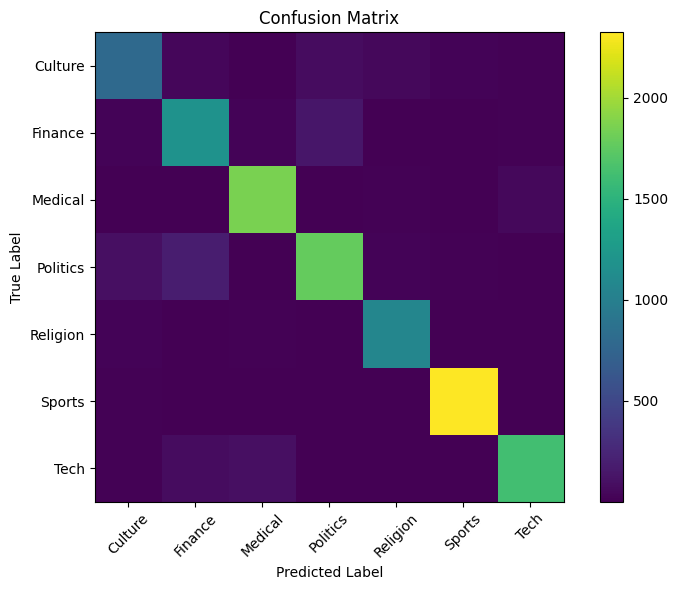

In [ ]:
# ==========================================
# Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np


# إنشاء المصفوفة
cm = confusion_matrix(
    y_test_encoded,
    y_pred
)


plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# أسماء الفئات
plt.xticks(
    np.arange(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    np.arange(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.colorbar()

plt.tight_layout()

plt.show()

Here The End Of Training
to Test and run The Model Use the Demo file
By Eng:Alzubair Abbas .
